# EDA 12 (v5) — Refined comparison map: correspondence framing

**Created 2026-07-29. Supersedes the v4 map cell** after supervisor/review feedback;
v3 and v4 remain on file as the record. Tree/Yee/enrichment cells are verbatim
from v3 so this runs standalone. **Inputs identical to v3/v4 — no new geojson.**

**Changes vs v4:**
1. **Neutral framing.** Title → *Correspondence between flow mechanisms and
   attribute-defined gentrification subtypes* ("vs" dropped). Panel headings →
   *2011 — contemporaneous comparison* / *2021 — later persistence comparison*
   ("validation"/"test" removed: independent measures compared, not one tested
   against the other).
2. **Marker legibility.** SupGen: larger hollow circle (s=30), purple stroke 1.6;
   MainGen: solid purple triangle (s=36) with thin white edge; both over a white
   halo (stroke 3.0). Legend notes the subtype indicators are **overlapping**
   (any-LSOA flags; one MSOA can carry both).
3. **Visual weight rebalanced.** Counter-led lightened to grey-blue `#9db8ce`
   (context, not signal); outflow-internal darkened to `#f8875f` and
   outflow-external deepened to `#e64a2e` so the headline SupGen×outflow-internal
   fill survives page-size reduction.
4. **Statistics moved to the caption.** The sub-map lines now state the pattern
   in words; exact lifts/q-values are printed below for the caption and live in
   Table 4.4.

Colour grammar centralised in **`flow_yee_palette.py` (v2)** at project root —
replace any earlier copy; EDA 5 / 10 / 11 import from it when regenerated.

**Output:** `outputs/comparison_figs/fig_eda12_yee_subtype_mechanism_map_v5_20260729.png`

In [6]:
# ── setup, inputs, EDA 9 mechanism tree (inline; verbatim from v3) ───────────
import sys
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats
from pyprojroot import here
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

pd.set_option('display.width', 200)

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs'
FIG_DIR    = OUT_DIR / 'comparison_figs'
NATF       = OUT_DIR / 'msoa_cascade_national_frame_20260625.csv'
EDA4       = OUT_DIR / 'eda4_results_for_phase3_20260626.csv'
YEE_LABELS = DATA_DIR / 'yee_LSOA_labels_forMapping.csv'
LOOKUP     = OUT_DIR / 'lsoa11_to_msoa11.csv'
GEO        = DATA_DIR / 'london_msoa_2011.geojson'

FIG_DIR.mkdir(parents=True, exist_ok=True)

INFLOW_MIN, EXT_MAJ = 0.25, 0.50   # EDA 9: empirically gapped / stated majority convention
LEAVES = ['inflow-driven', 'frame-sensitive', 'outflow-external', 'outflow-internal']

df = pd.read_csv(EDA4).merge(
    pd.read_csv(NATF)[['msoa11cd', 'Ext_Outflow_nat_11', 'Outflow_Poorer_nat_11',
                       'Ext_Outflow_nat_21', 'Outflow_Poorer_nat_21']], on='msoa11cd')

NAMES = next(p for p in (DATA_DIR / 'MSOA_2011_to_2021_lookup_for_identification.csv',
                         OUT_DIR  / 'MSOA_2011_to_2021_lookup_for_identification.csv') if p.exists())
nm = (pd.read_csv(NAMES, encoding='utf-8-sig')[['MSOA11CD', 'MSOA11NM']].drop_duplicates()
        .rename(columns={'MSOA11CD': 'msoa11cd', 'MSOA11NM': 'msoa_name'}))
df = df.merge(nm, on='msoa11cd', how='left')
assert df['msoa_name'].notna().all(), 'unnamed MSOAs after lookup merge'

# Ext arm share = Ext_Outflow_nat / Outflow_Poorer_nat, defined only above national D6
for yr in ('11', '21'):
    with np.errstate(divide='ignore', invalid='ignore'):
        s = df[f'Ext_Outflow_nat_{yr}'] / df[f'Outflow_Poorer_nat_{yr}']
    df[f'Ext_Arm_Share_{yr}'] = np.where(df['Wealth_Decile_National'] > 6, s.fillna(0), 0.0)

def leaf(r, yr):
    if r[f'Typ_C_{yr}'] != 'Cascade-led':
        return None
    if r[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN:
        return 'inflow-driven' if r[f'Typ_A_{yr}'] == 'Cascade-led' else 'frame-sensitive'
    return 'outflow-external' if r[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ else 'outflow-internal'

for yr in ('11', '21'):
    df[f'leaf_{yr}'] = df.apply(leaf, axis=1, yr=yr)
df['Genuine_Persistent'] = (df['leaf_11'] == 'inflow-driven') & (df['leaf_21'] == 'inflow-driven')

# guard: must reproduce the EDA 9 leaf counts exactly
assert df['leaf_11'].value_counts().to_dict() == {'outflow-internal': 81, 'frame-sensitive': 57,
                                                  'inflow-driven': 56, 'outflow-external': 19}
assert df['leaf_21'].value_counts().to_dict() == {'outflow-internal': 90, 'outflow-external': 78,
                                                  'frame-sensitive': 14, 'inflow-driven': 13}
assert df['Genuine_Persistent'].sum() == 8
print('tree reproduces EDA 9 exactly — 2011:', df.leaf_11.value_counts().to_dict())
print('                              2021:', df.leaf_21.value_counts().to_dict(),
      '| genuine persistent n =', df.Genuine_Persistent.sum())

tree reproduces EDA 9 exactly — 2011: {'outflow-internal': 81, 'frame-sensitive': 57, 'inflow-driven': 56, 'outflow-external': 19}
                              2021: {'outflow-internal': 90, 'outflow-external': 78, 'frame-sensitive': 14, 'inflow-driven': 13} | genuine persistent n = 8


In [7]:
# ── Yee labels: modal, any-GEN, Class-3 subtypes (verbatim from v3) ──────────
yee = pd.read_csv(YEE_LABELS).rename(columns={'LSOA_Code': 'lsoa11cd'})
lk  = pd.read_csv(LOOKUP)[['lsoa11cd', 'msoa11cd']].drop_duplicates().dropna()
yg  = yee.merge(lk, on='lsoa11cd', how='inner')
yg  = yg[yg['msoa11cd'].isin(df['msoa11cd'])].copy()
print(f'Yee LSOAs in frame: {len(yg)} across {yg.msoa11cd.nunique()}/{len(df)} MSOAs')

g = yg.groupby('msoa11cd')['Class_2_status']
modal = g.agg(lambda s: s.value_counts().index[0]).rename('yee_modal')
conf  = g.agg(lambda s: s.value_counts().iloc[0] / len(s)).rename('modal_confidence')
has_gen = (yg[yg['Class_2_status'] == 'GEN'].groupby('msoa11cd').size()
           .reindex(modal.index, fill_value=0) > 0).rename('has_gen')
df = df.merge(pd.concat([modal, conf, has_gen], axis=1),
              left_on='msoa11cd', right_index=True, how='left')
df['gen_modal'] = df['yee_modal'] == 'GEN'

for sub in ['SupGen', 'MainGen', 'MargGen']:
    df[f'any_{sub}'] = (yg[yg['Class_3_status'] == sub].groupby('msoa11cd').size()
                        .reindex(df['msoa11cd'], fill_value=0) > 0).values

print('modal GEN:', df.gen_modal.sum(), '| any-GEN:', df.has_gen.sum(),
      '| any-SupGen:', df.any_SupGen.sum(), '| any-MainGen:', df.any_MainGen.sum(),
      '| any-MargGen:', df.any_MargGen.sum())

Yee LSOAs in frame: 4830 across 982/982 MSOAs
modal GEN: 41 | any-GEN: 207 | any-SupGen: 94 | any-MainGen: 39 | any-MargGen: 101


In [8]:
# ── enrichment machinery + subtype table (only what the map footer needs) ────
def enrich(mask, gen, label):
    N, G = len(gen), int(gen.sum())
    n, k = int(mask.sum()), int((mask & gen).sum())
    rate, base = (k / n if n else np.nan), G / N
    OR, p = stats.fisher_exact([[k, n - k], [G - k, N - n - (G - k)]], alternative='two-sided')
    return dict(group=label, n=n, GEN=k, rate_pct=round(rate * 100, 1),
                base_pct=round(base * 100, 1), lift=round(rate / base, 2),
                OR=round(OR, 2), fisher_p=p)

def bh(pvals):
    p = np.asarray(pvals); m = len(p); order = np.argsort(p)
    q = np.empty(m); prev = 1.0
    for rank, i in list(enumerate(order, 1))[::-1]:
        prev = min(prev, p[i] * m / rank); q[i] = prev
    return q

rows = []
for sub in ['SupGen', 'MainGen', 'MargGen']:
    for yr in ('11', '21'):
        for lf in LEAVES:
            r = enrich(df[f'leaf_{yr}'] == lf, df[f'any_{sub}'], lf)
            r.update(year=f'20{yr}', subtype=sub); rows.append(r)
sub_tab = pd.DataFrame(rows)
sub_tab['bh_q'] = np.concatenate([bh(sub_tab.loc[sub_tab.subtype == s, 'fisher_p'])
                                  for s in ['SupGen', 'MainGen', 'MargGen']])
fmt = lambda v: f'{v:.4f}' if v >= 1e-4 else f'{v:.1e}'
for c in ['fisher_p', 'bh_q']: sub_tab[c] = sub_tab[c].map(fmt)
print(sub_tab[['subtype', 'year', 'group', 'n', 'GEN', 'lift', 'fisher_p', 'bh_q']]
      .to_string(index=False))

subtype year            group  n  GEN  lift fisher_p    bh_q
 SupGen 2011    inflow-driven 56    9  1.68   0.0995  0.1995
 SupGen 2011  frame-sensitive 57    6  1.10   0.8155  0.9320
 SupGen 2011 outflow-external 19    4  2.20   0.0998  0.1995
 SupGen 2011 outflow-internal 81   18  2.32   0.0005  0.0019
 SupGen 2021    inflow-driven 13    2  1.61   0.3580  0.5641
 SupGen 2021  frame-sensitive 14    1  0.75   1.0000  1.0000
 SupGen 2021 outflow-external 78    5  0.67   0.4231  0.5641
 SupGen 2021 outflow-internal 90   29  3.37  1.5e-10 1.2e-09
MainGen 2011    inflow-driven 56    5  2.25   0.0654  0.2653
MainGen 2011  frame-sensitive 57    4  1.77   0.2780  0.7413
MainGen 2011 outflow-external 19    0  0.00   1.0000  1.0000
MainGen 2011 outflow-internal 81    3  0.93   1.0000  1.0000
MainGen 2021    inflow-driven 13    0  0.00   1.0000  1.0000
MainGen 2021  frame-sensitive 14    0  0.00   1.0000  1.0000
MainGen 2021 outflow-external 78    0  0.00   0.0663  0.2653
MainGen 2021 outflow-int

In [9]:
# ── colour grammar: import from project root, inline fallback ────────────────
try:
    from flow_yee_palette import (FLOW_FILL, FLOW_ALPHA, FLOW_DRAW_ORDER,
                                  FLOW_LABEL, YEE, MARKER_STYLE)
    print('palette v2 imported from flow_yee_palette.py')
except ImportError:
    print('flow_yee_palette.py not found at project root — using inline fallback '
          '(identical values; place the module at ROOT so EDA 5/10/11 share it)')
    FLOW_FILL = {'inflow-driven': '#99000d', 'frame-sensitive': '#e6ab02',
                 'outflow-external': '#e64a2e', 'outflow-internal': '#f8875f',
                 'counter': '#9db8ce', 'other': '#e9e7e2'}
    FLOW_ALPHA = {'inflow-driven': 0.95, 'frame-sensitive': 0.90,
                  'outflow-external': 0.95, 'outflow-internal': 0.95,
                  'counter': 0.85, 'other': 1.00}
    FLOW_DRAW_ORDER = ('other', 'counter', 'outflow-internal',
                       'outflow-external', 'frame-sensitive', 'inflow-driven')
    FLOW_LABEL = {'inflow-driven': 'Inflow-driven cascade — frame-robust, inflow-led',
                  'frame-sensitive': 'Frame-sensitive inflow — residual',
                  'outflow-external': 'Outflow cascade — external-majority',
                  'outflow-internal': 'Outflow cascade — internal-majority',
                  'counter': 'Counter-led', 'other': 'Symmetric / Lateral'}
    YEE = {'GEN': '#762a83', 'marker': '#762a83'}
    MARKER_STYLE = dict(
        supgen=dict(s=30, facecolors='none', edgecolors=YEE['marker'], linewidths=1.6),
        maingen=dict(s=36, marker='^', facecolors=YEE['marker'], edgecolors='white', linewidths=0.7),
        halo_lw=3.0)

palette v2 imported from flow_yee_palette.py


2011: {'other': 489, 'counter': 280, 'outflow-internal': 81, 'frame-sensitive': 57, 'inflow-driven': 56, 'outflow-external': 19}
2021: {'counter': 452, 'other': 335, 'outflow-internal': 90, 'outflow-external': 78, 'frame-sensitive': 14, 'inflow-driven': 13}


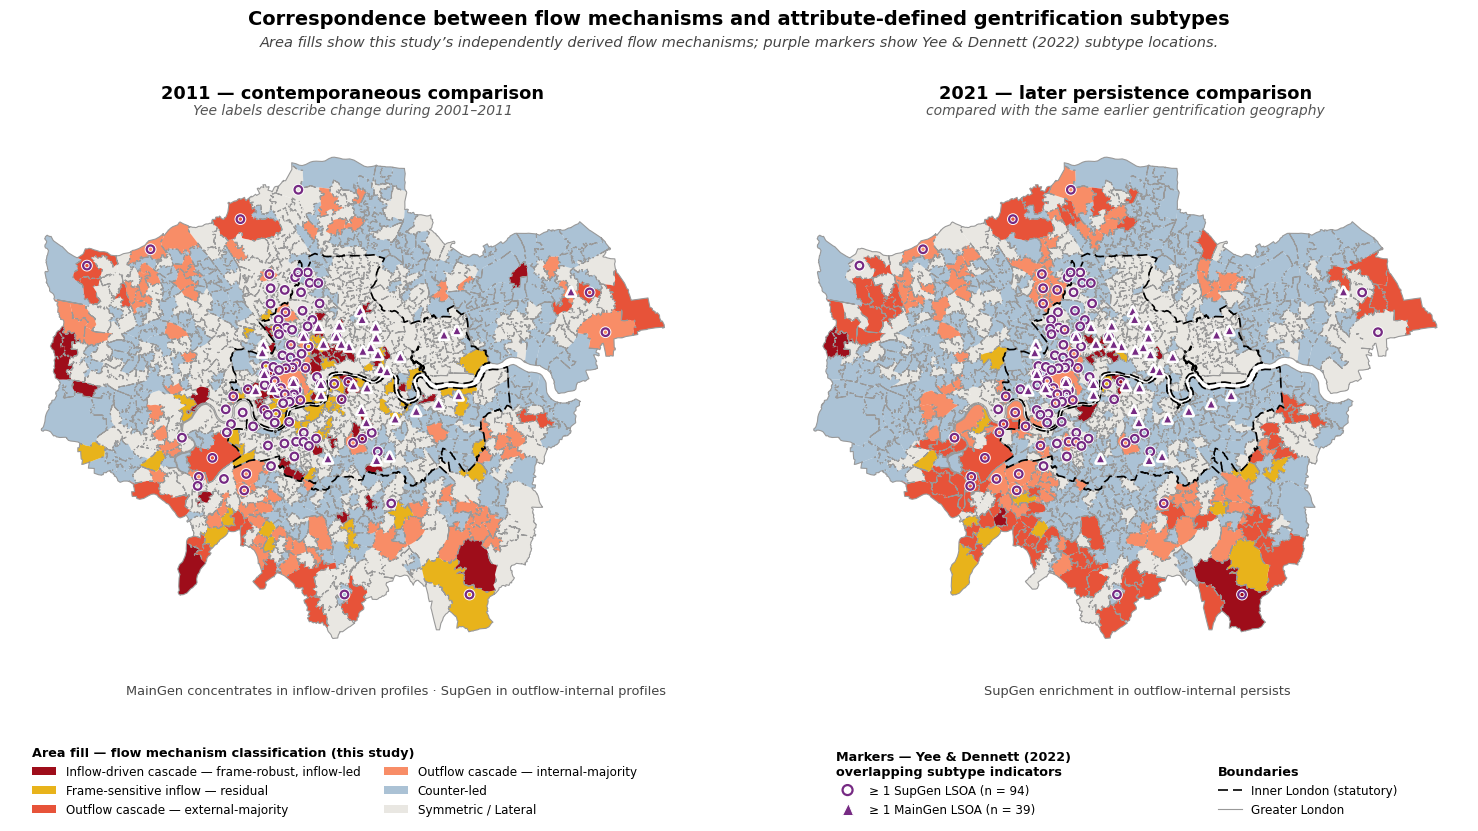


Caption statistics (paste into the figure caption / cross-ref Table 4.4):
  2011: SupGen × outflow-internal: lift 2.32 (q = 0.0019)   ·   MainGen × inflow-driven: lift 2.25 (p = 0.0654)
  2021: SupGen × outflow-internal: lift 3.37 (q = 1.2e-09)   ·   MainGen × inflow-driven: 0 of 13

2011 markers per class:
                  any_SupGen  any_MainGen
map_class_11                             
counter                    6            4
frame-sensitive            6            4
inflow-driven              9            5
other                     51           23
outflow-external           4            0
outflow-internal          18            3

2021 markers per class:
                  any_SupGen  any_MainGen
map_class_21                             
counter                   25           19
frame-sensitive            1            0
inflow-driven              2            0
other                     32           18
outflow-external           5            0
outflow-internal          29       

In [10]:
# ── v5 map: correspondence framing, refined markers, rebalanced weights ──────
def map_class(r, yr):
    lf = r[f'leaf_{yr}']
    if isinstance(lf, str):
        return lf
    return 'counter' if r[f'Typ_C_{yr}'] == 'Counter-led' else 'other'

for yr in ('11', '21'):
    df[f'map_class_{yr}'] = df.apply(map_class, axis=1, yr=yr)
    print(f'20{yr}:', df[f'map_class_{yr}'].value_counts().to_dict())

gdf = gpd.read_file(GEO).rename(columns={'MSOA11CD': 'msoa11cd'})
if gdf.crs is None or gdf.crs.to_epsg() != 27700:
    gdf = gdf.set_crs(4326, allow_override=(gdf.crs is None)).to_crs(27700)
g = gdf.merge(df, on='msoa11cd', how='left')

# Camden 024/025 merge: E02000190 inherits E02000189 (same convention as EDA 10)
if (g.msoa11cd == 'E02000190').any() and g.loc[g.msoa11cd == 'E02000190', 'Ring'].isna().all():
    donor = g[g.msoa11cd == 'E02000189'].iloc[0]
    m = g.msoa11cd == 'E02000190'
    for c in df.columns:
        if c != 'msoa11cd':
            g.loc[m, c] = donor[c]
    g.loc[m, ['any_SupGen', 'any_MainGen', 'any_MargGen']] = False

outer_outline = g.dissolve()
inner = g[g['Ring'] == 'Inner'].dissolve()
inner.geometry = inner.buffer(25).buffer(-25)

# caption statistics (exact values live in the caption / Table 4.4, not on the map)
def _fmt_stat(sub, yr, lf, use_q=False):
    r = sub_tab[(sub_tab.subtype == sub) & (sub_tab.year == f'20{yr}') & (sub_tab.group == lf)].iloc[0]
    if r.GEN == 0:
        return f'{r.GEN} of {r.n}'
    return f"lift {r['lift']} ({'q = ' + r.bh_q if use_q else 'p = ' + r.fisher_p})"

CAPTION_STATS = {yr: (f"SupGen \u00d7 outflow-internal: {_fmt_stat('SupGen', yr, 'outflow-internal', use_q=True)}"
                      f"   \u00b7   MainGen \u00d7 inflow-driven: {_fmt_stat('MainGen', yr, 'inflow-driven')}")
                 for yr in ('11', '21')}

TITLES = {'11': ('2011 \u2014 contemporaneous comparison',
                 'Yee labels describe change during 2001\u20132011'),
          '21': ('2021 \u2014 later persistence comparison',
                 'compared with the same earlier gentrification geography')}
ANNOT  = {'11': 'MainGen concentrates in inflow-driven profiles \u00b7 SupGen in outflow-internal profiles',
          '21': 'SupGen enrichment in outflow-internal persists'}

HALO = [pe.withStroke(linewidth=MARKER_STYLE['halo_lw'], foreground='white')]

fig, axes = plt.subplots(1, 2, figsize=(15.6, 8.3))
for ax, yr in zip(axes, ('11', '21')):
    for cls in FLOW_DRAW_ORDER:
        sub = g[g[f'map_class_{yr}'] == cls]
        if len(sub):
            sub.plot(ax=ax, color=FLOW_FILL[cls], alpha=FLOW_ALPHA[cls], edgecolor='none')
    outer_outline.boundary.plot(ax=ax, color='#999999', linewidth=0.8, zorder=4)
    inner.boundary.plot(ax=ax, color='black', linewidth=1.2, linestyle=(0, (6, 3)), zorder=5)
    cent = g.geometry.representative_point()
    ms = g['any_SupGen'].fillna(False).astype(bool)
    mm = g['any_MainGen'].fillna(False).astype(bool)
    ax.scatter(cent[ms].x, cent[ms].y, zorder=6, path_effects=HALO, **MARKER_STYLE['supgen'])
    ax.scatter(cent[mm].x, cent[mm].y, zorder=7, path_effects=HALO, **MARKER_STYLE['maingen'])
    t, s = TITLES[yr]
    ax.set_title(t + '\n', fontsize=12.8, fontweight='bold', pad=10)
    ax.text(0.5, 1.035, s, transform=ax.transAxes, ha='center', fontsize=10,
            style='italic', color='#555555')
    ax.set_axis_off()

fig.text(0.28, 0.165, ANNOT['11'], ha='center', fontsize=9.3, color='#444444')
fig.text(0.755, 0.165, ANNOT['21'], ha='center', fontsize=9.3, color='#444444')

fill_handles = [mpatches.Patch(fc=FLOW_FILL[c], alpha=FLOW_ALPHA[c], label=FLOW_LABEL[c])
                for c in ('inflow-driven', 'frame-sensitive', 'outflow-external',
                          'outflow-internal', 'counter', 'other')]
yee_handles = [
    Line2D([0], [0], marker='o', ls='', mfc='none', mec=YEE['marker'], mew=1.6,
           markersize=7.2, path_effects=HALO,
           label=f'\u2265 1 SupGen LSOA (n = {int(df.any_SupGen.sum())})'),
    Line2D([0], [0], marker='^', ls='', mfc=YEE['marker'], mec='white', mew=0.7,
           markersize=8, path_effects=HALO,
           label=f'\u2265 1 MainGen LSOA (n = {int(df.any_MainGen.sum())})'),
]
bnd_handles = [
    Line2D([0], [0], color='black', lw=1.2, ls=(0, (6, 3)), label='Inner London (statutory)'),
    Line2D([0], [0], color='#999999', lw=0.8, label='Greater London'),
]
l1 = fig.legend(handles=fill_handles, loc='lower left', bbox_to_anchor=(0.04, 0.005),
                ncol=2, frameon=False, fontsize=8.6, alignment='left',
                title='Area fill \u2014 flow mechanism classification (this study)')
l2 = fig.legend(handles=yee_handles, loc='lower left', bbox_to_anchor=(0.555, 0.005),
                ncol=1, frameon=False, fontsize=8.6, alignment='left',
                title='Markers \u2014 Yee & Dennett (2022)\noverlapping subtype indicators')
l3 = fig.legend(handles=bnd_handles, loc='lower left', bbox_to_anchor=(0.80, 0.005),
                ncol=1, frameon=False, fontsize=8.6, alignment='left', title='Boundaries')
for l in (l1, l2, l3):
    l.get_title().set_fontweight('bold'); l.get_title().set_fontsize(9.2)

fig.suptitle('Correspondence between flow mechanisms and '
             'attribute-defined gentrification subtypes',
             fontsize=14, fontweight='bold', y=0.99)
fig.text(0.5, 0.945, 'Area fills show this study\u2019s independently derived flow mechanisms; '
         'purple markers show Yee & Dennett (2022) subtype locations.',
         ha='center', fontsize=10.5, style='italic', color='#444444')

plt.tight_layout(rect=[0, 0.185, 1, 0.90])
fig.savefig(FIG_DIR / 'fig_eda12_yee_subtype_mechanism_map_v5_20260729.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print('\nCaption statistics (paste into the figure caption / cross-ref Table 4.4):')
for yr in ('11', '21'):
    print(f'  20{yr}: {CAPTION_STATS[yr]}')
for yr in ('11', '21'):
    print(f'\n20{yr} markers per class:')
    print(df.groupby(f'map_class_{yr}')[['any_SupGen', 'any_MainGen']].sum().to_string())

## Draft caption (paste into Results 4.5.3; insert printed statistics)

> **Figure 4.x. Correspondence between flow mechanisms and Yee & Dennett (2022)
> gentrification subtypes.** Area fills show the flow-mechanism classification
> developed in this study (EDA 9 time-symmetric tree; warm hues = cascade
> leaves, blue = Counter-led, grey = Symmetric/Lateral). Purple markers show an
> independently derived classification: MSOAs containing at least one LSOA
> labelled SupGen (○) or MainGen (▲) by Yee & Dennett's attribute-based
> method; the indicators are overlapping, so one MSOA can carry both. The two
> layers are independently classified — their spatial coincidence indicates
> correspondence, not equivalence. In the 2011 contemporaneous comparison,
> mainstream gentrification concentrates selectively among inflow-driven,
> frame-robust profiles [MainGen × inflow-driven: …], while
> super-gentrification is over-represented among outflow-internal-majority
> profiles in both comparisons [SupGen × outflow-internal: 2011 …;
> 2021 …]. Enrichment lifts with Fisher's exact tests, BH-corrected q where
> stated; full table in Table 4.4.

## Follow-up (same grammar, other figures)

- **EDA 10 mechanism maps**: import `FLOW_FILL`/`FLOW_ALPHA` from
  `flow_yee_palette.py` (counter and both outflow hexes changed in v2).
- **EDA 5 divergence map (Fig 4.21)**: recolour with `DIVERGENCE`
  (red = flow-only, purple = Yee-only, green = agree).
- **EDA 11 alluvials**: counter arms → `ALLUVIAL['counter_in']` /
  `['counter_ex']` so ribbons match the maps.